# 241 Final Project EDA

**Data pulled on July 25th, 2026**

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open("/ai-experiment-data-241-default-rtdb-export (2).json") as f:
    data = json.load(f)

print(list(data.keys()))
#print(data['config'])
is_active = data.get("config")["is_experiment_active"]
print(f"is_experiment_active: {is_active}")

['config', 'logs']
is_experiment_active: True


### Future cleaning for post-experiment

In [6]:
# # Set to the UTC time that is_experiment_active was flipped to true in Firebase.
# # Everything before this is pilot / testing data and should be excluded.

# LAUNCH_DATETIME_UTC = "2026-07-26T00:00:00Z"
# LAUNCH_TS = pd.Timestamp(LAUNCH_DATETIME_UTC)

# clean = df.copy()

# # Drop pre-experiment logs
# before = len(clean)
# clean = clean[clean["timestamp"] >= LAUNCH_TS]

# print(f"Rows remaining:           {len(clean)}")
# print(f"Participants remaining:   {clean['userId'].nunique()}")


In [25]:
# logs = data["logs"]
# print(f"Total logs: {len(logs)}")

# Turn the logs dict into a DataFrame for easier analysis
df = pd.DataFrame.from_dict(logs, orient="index")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

# Set to the UTC time for filtering data after 2026-06-22
LAUNCH_DATETIME_UTC = "2026-07-23T00:00:00Z"
LAUNCH_TS = pd.Timestamp(LAUNCH_DATETIME_UTC)

# Filter the main DataFrame `df`
df = df[df["timestamp"] > LAUNCH_TS]

df.head()

,durationSeconds,isExperimentOn,newChatClicks,platform,timestamp,type,userId,buttonName,group,timestampPacific
-OyCHkPT2JTyxlOqzHKl,5.0,False,0.0,Gemini,2026-07-23 04:45:31.921000+00:00,LOG_SESSION_TIME,user_iyosu4msax8tebmyyspko,NaN,control,"7/22/2026, 9:45:31 PM"
-OyCLxNFT-4JxqLCU81Y,201.0,False,0.0,ChatGPT,2026-07-23 05:03:53.742000+00:00,LOG_SESSION_TIME,user_cwkz2wemuhnw0sgr8rt9,NaN,control,"7/22/2026, 10:03:53 PM"
-OyCM81S7ycy6y3k0N7a,34.0,False,0.0,ChatGPT,2026-07-23 05:04:41.583000+00:00,LOG_SESSION_TIME,user_cwkz2wemuhnw0sgr8rt9,NaN,control,"7/22/2026, 10:04:41 PM"
-OyCMELMsQYzDs9d32Bp,NaN,False,NaN,ChatGPT,2026-07-23 05:05:07.444000+00:00,NEW_CHAT_CLICK,user_cwkz2wemuhnw0sgr8rt9,New Chat,control,"7/22/2026, 10:05:07 PM"
-OyCNTQ87OX52sza_xHz,NaN,False,NaN,ChatGPT,2026-07-23 05:10:31.334000+00:00,NEW_CHAT_CLICK,user_cwkz2wemuhnw0sgr8rt9,New Chat,control,"7/22/2026, 10:10:31 PM"


In [26]:
# Only LOG_SESSION_TIME rows carry a duration
df_chat_duration = df[df["type"] == "LOG_SESSION_TIME"].copy()
df["durationSeconds"] = df["durationSeconds"].astype(float)

print(f"Sessions for analysis: {len(df_chat_duration)}")
print(f"Active Participants:   {df_chat_duration['userId'].nunique()}")

Sessions for analysis: 26
Active Participants:   10


## Total number of participants (unique userIds)

In [27]:
unique_users = df["userId"].nunique()
print(f"Number of active participants: {unique_users}")

Number of active participants: 10


## Breakdown by event type

In [28]:
event_counts = df["type"].value_counts()
print(event_counts)
print()
print("Usage:")
print(f"  First log: {df['timestamp'].min().date()}")
print(f"  Last log:  {df['timestamp'].max().date()}")

type
LOG_SESSION_TIME    26
NEW_CHAT_CLICK       8
Name: count, dtype: int64

Usage:
  First log: 2026-07-23
  Last log:  2026-07-27


## Number of participants per platform

Note: a participant can appear across multiple platforms, so these will not necessarily sum to the total # of participants.

In [29]:
platform_users = df.groupby("platform")["userId"].nunique().sort_values(ascending=False)
print(platform_users)

platform
ChatGPT    5
Claude     3
Gemini     3
Name: userId, dtype: int64


In [30]:
# Build DataFrame with one row per user, and a column with a list of the platforms they use
user_platforms = (
    df.groupby("userId")["platform"]
      .agg(lambda s: sorted(set(s)))
      .reset_index(name="platforms")
)

# Count how many platforms each user used
user_platforms["platforms_used"] = user_platforms["platforms"].apply(len)

# How many users used how many platforms?
print(user_platforms["platforms_used"]
      .value_counts()
      .sort_index()
      .rename_axis("platforms_used")
      .reset_index(name="user_count")
      .to_string(index=False)
)

# Users who use more than one platform
multi_platform_users = user_platforms[user_platforms["platforms_used"] > 1]
multi_platform_users.head()

 platforms_used  user_count
              1           9
              2           1


,userId,platforms,platforms_used
7,user_y1mj94c9ilhroidrjs3ueh,"[ChatGPT, Gemini]",2


## Sign-ups, over time

In [31]:
#  First-seen date (creation) of userId
first_seen = df.groupby("userId")["timestamp"].min().dt.date
signups_per_day = first_seen.value_counts().sort_index()
cumulative_signups = signups_per_day.cumsum()

summary = pd.DataFrame({
    "new_participants": signups_per_day,
    "cumulative_participants": cumulative_signups
})
summary


,new_participants,cumulative_participants
timestamp,,
2026-07-23,3,3
2026-07-24,3,6
2026-07-25,1,7
2026-07-26,2,9
2026-07-27,1,10


## Initial EDA Summary

In [32]:
print(f"Experiment active? {is_active}")
print()
print(f"Total logs:                     {len(logs)}")
print(f"    Total # of participants:    {unique_users}")
print(f"    Total # of chats:           {event_counts.get('LOG_SESSION_TIME', 0)}")
print(f"    Total 'New Chat' clicks:    {event_counts.get('NEW_CHAT_CLICK', 0)}")
print()
print("Total users per platform:")
print(platform_users.to_string())


Experiment active? True

Total logs:                     216
    Total # of participants:    10
    Total # of chats:           26
    Total 'New Chat' clicks:    8

Total users per platform:
platform
ChatGPT    5
Claude     3
Gemini     3


# Chat Duration EDA

In [33]:
dur = df["durationSeconds"].dropna()

print(f"Min:       {dur.min():.0f} s")
print(f"Max:       {dur.max():.0f} s  ({dur.max()/60:.1f} min)")
print(f"Mean:      {dur.mean():.1f} s")
print(f"Median:    {dur.median():.0f} s")
print(f"Std:       {dur.std():.1f} s")
print()
print("Percentiles")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p:>2}th: {np.percentile(dur, p):>8.1f} s")


Min:       0 s
Max:       8980 s  (149.7 min)
Mean:      627.1 s
Median:    18 s
Std:       1821.8 s

Percentiles
  10th:      0.5 s
  25th:      3.5 s
  50th:     17.5 s
  75th:    206.2 s
  90th:   1263.5 s
  95th:   2529.8 s
  99th:   7453.2 s


## Chat duration by group and by platform

In [ ]:
if df_chat_duration["group"].notna().any():
    by_group = df_chat_duration.groupby("group")["durationSeconds"].agg(
        sessions="count", min="min", median="median", mean="mean", max="max"
        ).round(1)

    by_group.insert(1, "participants", df_chat_duration.groupby("group")["userId"].nunique())

print(by_group.to_string())

           sessions  participants  min  median  mean     max
group                                                       
control          69            13  0.0     3.0  37.6  1027.0
treatment        51            11  0.0     4.0  29.3   894.0


In [ ]:
by_platform = df_chat_duration.groupby("platform")["durationSeconds"].agg(
    sessions="count", min="min", median="median", mean="mean", max="max"
    ).sort_values("sessions", ascending=False).round(1)

by_platform

,sessions,min,median,mean,max
platform,,,,,
Gemini,69,0.0,4.0,21.0,446.0
ChatGPT,37,0.0,4.0,70.0,1027.0
Claude,17,1.0,3.0,14.2,155.0
Grok,14,1.0,4.5,8.2,21.0
DeepSeek,13,0.0,3.0,4.3,13.0


## Distribution of chat duration

- **(a)** the raw histogram, with mean and median marked
- **(b)** the same data on a log axis, which spreads out the short sessions
- **(c)** the empirical CDF, so any percentile can be read straight off the curve

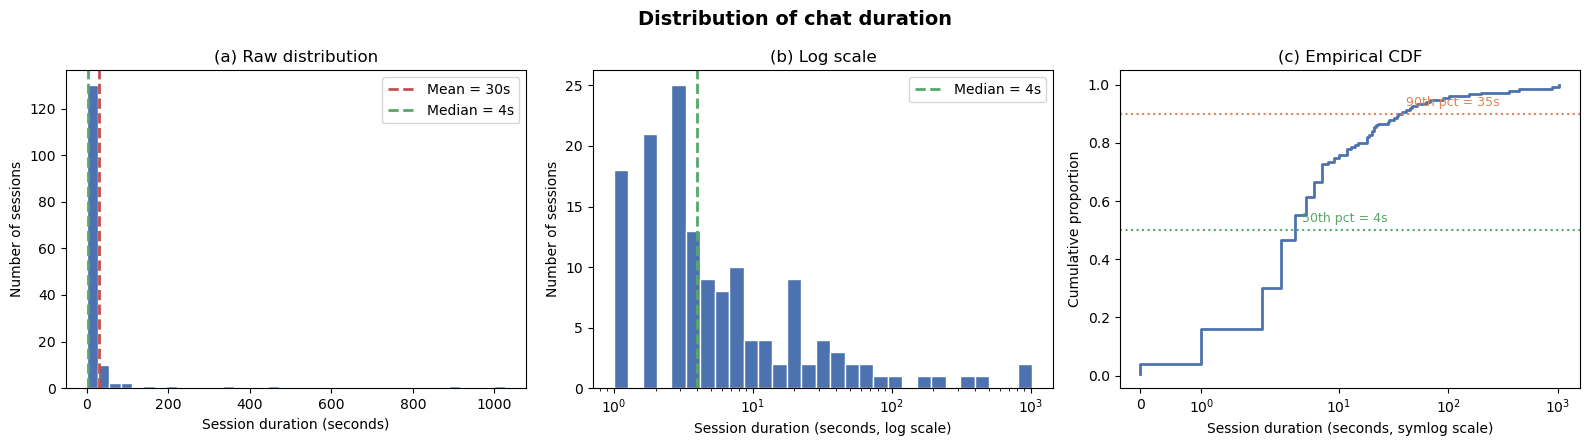

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Raw histogram
ax = axes[0]
ax.hist(dur, bins=min(40, max(10, len(dur) // 4)), color="#4C72B0", edgecolor="white")
ax.axvline(dur.mean(), color="#C44E52", ls="--", lw=2, label=f"Mean = {dur.mean():.0f}s")
ax.axvline(dur.median(), color="#55A868", ls="--", lw=2, label=f"Median = {dur.median():.0f}s")
ax.set_xlabel("Session duration (seconds)")
ax.set_ylabel("Number of sessions")
ax.set_title("(a) Raw distribution")
ax.legend()

# (b) Log-scale histogram
ax = axes[1]
nonzero = dur[dur > 0]
if len(nonzero) > 1 and nonzero.min() < nonzero.max():
    bins = np.logspace(np.log10(nonzero.min()), np.log10(nonzero.max()), 30)
    ax.hist(nonzero, bins=bins, color="#4C72B0", edgecolor="white")
    ax.set_xscale("log")
    ax.axvline(nonzero.median(), color="#55A868", ls="--", lw=2,
               label=f"Median = {nonzero.median():.0f}s")
    ax.legend()
ax.set_xlabel("Session duration (seconds, log scale)")
ax.set_ylabel("Number of sessions")
ax.set_title(f"(b) Log scale")

# (c) Empirical CDF
ax = axes[2]
x = np.sort(dur)
y = np.arange(1, len(x) + 1) / len(x)
ax.step(x, y, where="post", color="#4C72B0", lw=2)
ax.set_xscale("symlog")
for p, c in [(50, "#55A868"), (90, "#DD8452")]:
    v = np.percentile(dur, p)
    ax.axhline(p / 100, color=c, ls=":", lw=1.5)
    ax.annotate(f"{p}th pct = {v:.0f}s", xy=(v, p / 100), xytext=(5, 6),
                textcoords="offset points", color=c, fontsize=9)
ax.set_xlabel("Session duration (seconds, symlog scale)")
ax.set_ylabel("Cumulative proportion")
ax.set_title("(c) Empirical CDF")

fig.suptitle(f"Distribution of chat duration", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

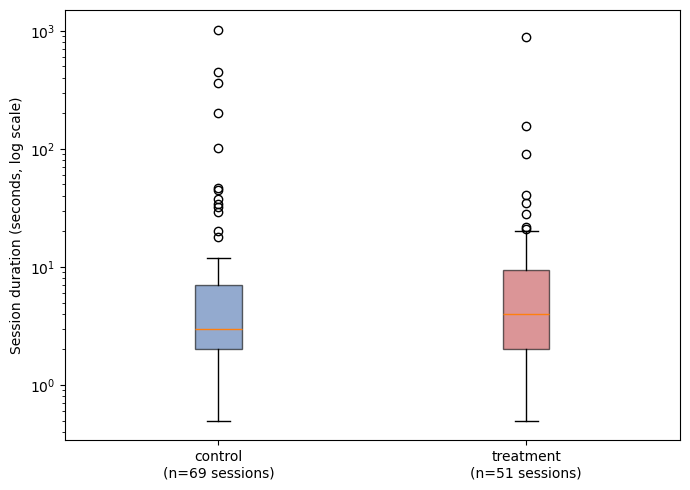

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
order = ["control", "treatment"]
data = [df_chat_duration.loc[df_chat_duration["group"] == g, "durationSeconds"].clip(lower=0.5)
        for g in order]

n_by_group = {g: int((df_chat_duration["group"] == g).sum()) for g in order}
labels = [f"{g}\n(n={n_by_group[g]} sessions)" for g in order]

bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, showfliers=True)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#C44E52"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_yscale("log")
ax.set_ylabel("Session duration (seconds, log scale)")

plt.tight_layout()
plt.show()
